# Soldani - First task - Adult Exploration

In this first task, we start from the processed adult dataset and perform:
- mathematical computations to calculate numerical effects
- full LLM-based analysis
- graph construction using pgmpy
- tracking of time and token usage (standard and reasoning tokens)
- application of different prompt engineering techniques

## 1. Initial setup

In [43]:
# Find the root
from pathlib import Path
import sys

# trova la root cercando la cartella "src"
current = Path.cwd()

while current != current.parent:
    if (current / "src").exists():
        REPO_ROOT = current
        break
    current = current.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## 2. Load data

In [44]:
data_path = REPO_ROOT/"data"/"processed"/"adult.csv"
df = pd.read_csv(data_path)

## 3. Schema
The first step is to explore the dataset in order to understand its structure and make informed decisions during the analysis.

In [45]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head(3)

Rows: 48842, Columns: 13


,S1_age,workclass,education,marital-status,occupation,relationship,S3_race,S2_gender,capital-gain,capital-loss,hours-per-week,native-country,T_income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


For each column, we can analyse the type, the amount of unique/missing values and some samples.

In [46]:
schema = pd.DataFrame({
    "dtype":            df.dtypes,
    "n_unique":         df.nunique(),
    "missing":          df.isna().sum(),
    "missing_%":        (df.isna().mean()*100).round(2),
    "sample_values":    [df[c].dropna().unique()[:4].tolist() for c in df.columns]
})
schema

,dtype,n_unique,missing,missing_%,sample_values
S1_age,int64,74,0,0.0,"[25, 38, 28, 44]"
workclass,object,9,0,0.0,"[Private, Local-gov, Other, Self-emp-not-inc]"
education,object,16,0,0.0,"[11th, HS-grad, Assoc-acdm, Some-college]"
marital-status,object,7,0,0.0,"[Never-married, Married-civ-spouse, Widowed, D..."
occupation,object,15,0,0.0,"[Machine-op-inspct, Farming-fishing, Protectiv..."
relationship,object,6,0,0.0,"[Own-child, Husband, Not-in-family, Unmarried]"
S3_race,object,5,0,0.0,"[Black, White, Asian-Pac-Islander, Other]"
S2_gender,object,2,0,0.0,"[Male, Female]"
capital-gain,int64,123,0,0.0,"[0, 7688, 3103, 6418]"
capital-loss,int64,99,0,0.0,"[0, 1721, 1876, 2415]"


## 4. SFM roles
In this case, we manually assign gender to X variable, total income to Y, hours per week to W and education to Z.

In [47]:
TARGET = "T_income"
PROTECTED = "S2_gender"
MEDIATORS = ["hours-per-week"] # W
CONFOUNDERS = ["education"] # Z

print("Target:    ", TARGET)
print("Protected: ", PROTECTED)
print("Mediators: ", MEDIATORS)
print("Confounders:", CONFOUNDERS)

Target:     T_income
Protected:  S2_gender
Mediators:  ['hours-per-week']
Confounders: ['education']


## 5. Target Y
We build some distribution graphs on the target variable (Y) in order to see if the dataset is balanced or not.

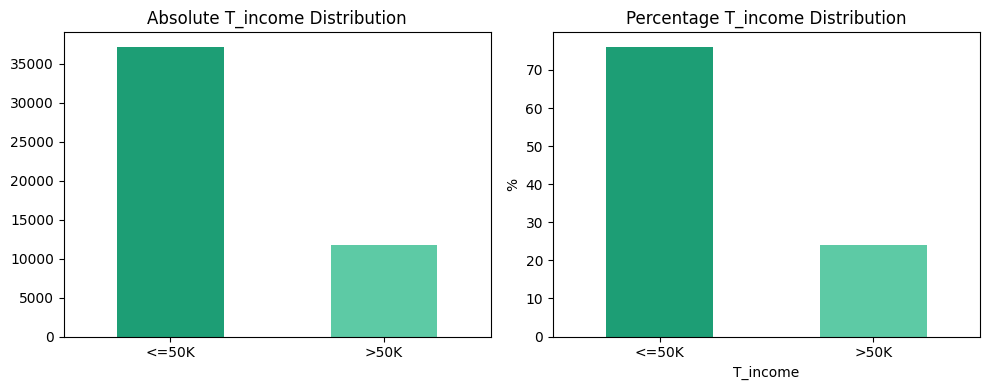

In [48]:
pythonfig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Absolute
df[TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["#1D9E75", "#5DCAA5"])
axes[0].set_title(f"Absolute {TARGET} Distribution")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Percentage
df[TARGET].value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[1], color=["#1D9E75", "#5DCAA5"])
axes[1].set_title(f"Percentage {TARGET} Distribution")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 6. Protected X

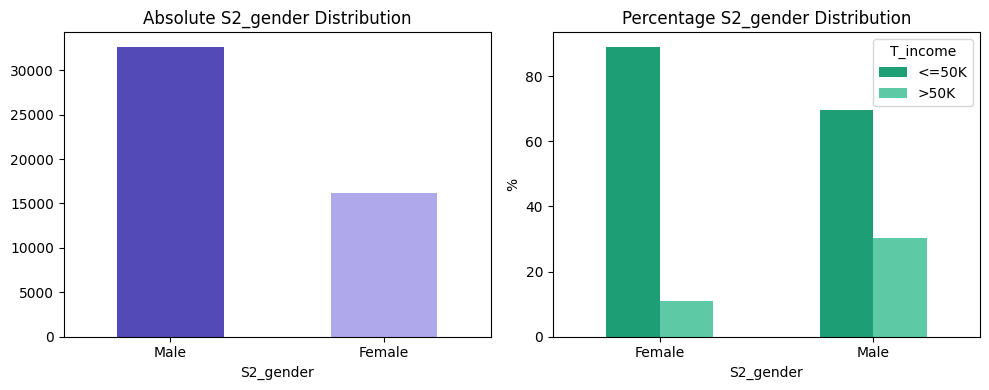

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df[PROTECTED].value_counts().plot(kind="bar", ax=axes[0], color=["#534AB7", "#AFA9EC"])
axes[0].set_title(f"Absolute {PROTECTED} Distribution")
axes[0].tick_params(axis="x", rotation=0)

ct = pd.crosstab(df[PROTECTED], df[TARGET], normalize="index") * 100
ct.plot(kind="bar", ax=axes[1], color=["#1D9E75", "#5DCAA5"])
axes[1].set_title(f"Percentage {PROTECTED} Distribution")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title=TARGET)

plt.tight_layout()
plt.show()

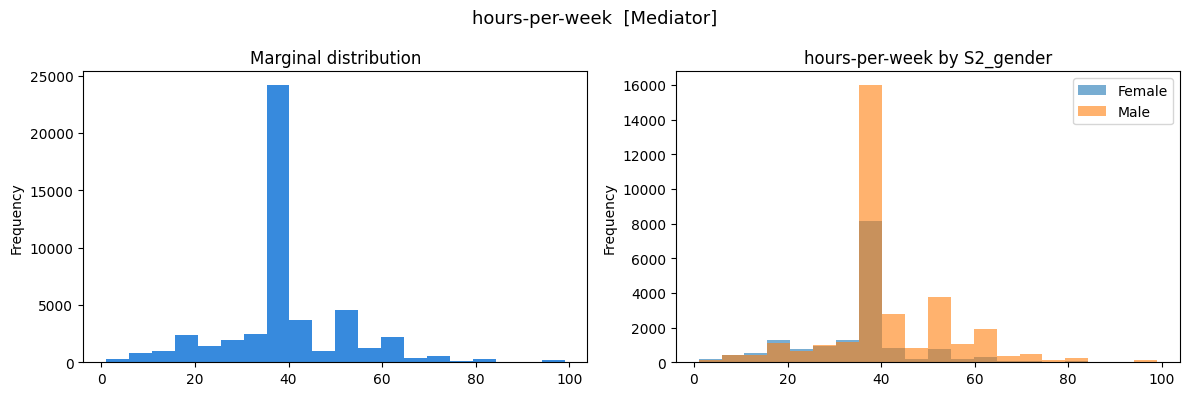

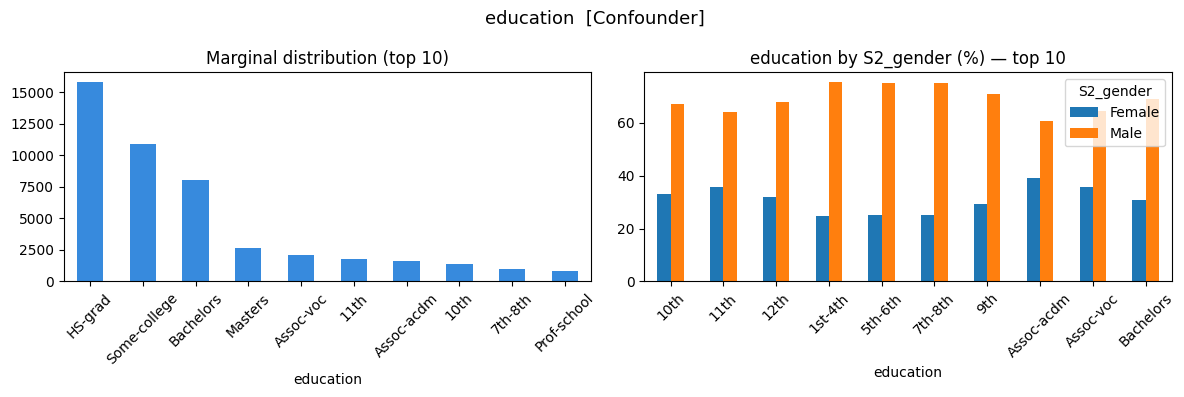

In [50]:
all_vars = MEDIATORS + CONFOUNDERS

for var in all_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    role = "Mediator" if var in MEDIATORS else "Confounder"
    fig.suptitle(f"{var}  [{role}]", fontsize=13)

    # Marginal distribution
    if df[var].dtype in ["int64", "float64"]:
        df[var].plot(kind="hist", bins=20, ax=axes[0], color="#378ADD")
        axes[0].set_title("Marginal distribution")
    else:
        df[var].value_counts().head(10).plot(kind="bar", ax=axes[0], color="#378ADD")
        axes[0].set_title("Marginal distribution (top 10)")
        axes[0].tick_params(axis="x", rotation=45)

    # Grouped distribution by X
    if df[var].dtype in ["int64", "float64"]:
        for grp, grp_df in df.groupby(PROTECTED):
            grp_df[var].plot(kind="hist", bins=20, ax=axes[1], alpha=0.6, label=grp)
        axes[1].set_title(f"{var} by {PROTECTED}")
        axes[1].legend()
    else:
        ct = pd.crosstab(df[var], df[PROTECTED], normalize="index") * 100
        ct.head(10).plot(kind="bar", ax=axes[1])
        axes[1].set_title(f"{var} by {PROTECTED} (%) — top 10")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].legend(title=PROTECTED)

    plt.tight_layout()
    plt.show()

In [51]:
# This is the "raw" Total Variation before any causal adjustment
groups = df.groupby(PROTECTED)[TARGET].value_counts(normalize=True).unstack()

print("P(Y | X) by group:\n")
print(groups.round(4))

x0, x1 = sorted(df[PROTECTED].unique())[:2]

tv = 0.5 * abs(groups.loc[x1] - groups.loc[x0]).sum()

print(f"\nRaw Total Variation ({x1} vs {x0}): {tv:.4f}")

P(Y | X) by group:

T_income    <=50K    >50K
S2_gender                
Female     0.8907  0.1093
Male       0.6962  0.3038

Raw Total Variation (Male vs Female): 0.1945
